In [5]:
import pandas as pd

def generate_defense_system_matrices(input_file):
    # 1. 读取CSV文件
    # 假设文件没有复杂的表头，直接以逗号分隔
    df = pd.read_csv(input_file)

    # 2. 检查数据完整性（确保所需的列都存在）
    required_columns = {'Environment', 'System', 'Sample', 'TPM'}
    if not required_columns.issubset(df.columns):
        raise ValueError(f"输入文件缺失必要的列，请确保包含: {required_columns}")

    # 3. 获取所有独特的环境类型
    environments = df['Environment'].unique()
    systems = df['System'].unique()
    print(f"检测到 {len(environments)} 种不同的环境: {', '.join(environments)}")

    # 4. 遍历每种环境，进行数据重塑并导出
    for env in environments:
        # 提取当前环境的子集
        df_env = df[df['Environment'] == env]

        # 使用 pivot_table 构建矩阵
        # index: 样本名为行
        # columns: 防御系统名为列
        # values: 填充TPM值
        # fill_value=0: 如果某个样本缺乏某种防御系统，则TPM补0
        matrix = df_env.pivot_table(
            index='Sample',
            columns='System',
            values='TPM',
            fill_value=0,
            aggfunc='mean' # 默认聚合函数。如果同一个样本中出现了重复的同一个防御系统名，将计算其均值
        )

        # 5. 生成输出文件
        # 文件名格式例如：bee-gut_defense_matrix.csv
        matrix = matrix.reindex(columns=systems, fill_value=0)
        output_filename = f"DS_ADS_spearman_matrix/{env}_defense_matrix.csv"
        matrix.to_csv(output_filename)

        print(f"已生成: {output_filename} | 矩阵维度: {matrix.shape[0]} 个样本 x {matrix.shape[1]} 种系统")

if __name__ == "__main__":
    # 使用时，将 'your_data.csv' 替换为你的实际文件路径
    input_filepath = r"C:\Users\jingqing\Desktop\all_environments_DS_long.csv"

    try:
        generate_defense_system_matrices(input_filepath)
    except Exception as e:
        print(f"处理数据时出现错误: {e}")

检测到 6 种不同的环境: bee-gut, freshwater, human-gut, marine, pig-gut, soil
已生成: DS_ADS_spearman_matrix/bee-gut_defense_matrix.csv | 矩阵维度: 6 个样本 x 207 种系统
已生成: DS_ADS_spearman_matrix/freshwater_defense_matrix.csv | 矩阵维度: 14 个样本 x 207 种系统
已生成: DS_ADS_spearman_matrix/human-gut_defense_matrix.csv | 矩阵维度: 10 个样本 x 207 种系统
已生成: DS_ADS_spearman_matrix/marine_defense_matrix.csv | 矩阵维度: 21 个样本 x 207 种系统
已生成: DS_ADS_spearman_matrix/pig-gut_defense_matrix.csv | 矩阵维度: 14 个样本 x 207 种系统
已生成: DS_ADS_spearman_matrix/soil_defense_matrix.csv | 矩阵维度: 15 个样本 x 207 种系统


In [6]:
import os
import glob
import pandas as pd
import numpy as np

def perform_clr_transformation(df, epsilon=1e-6):
    """
    对表达量矩阵进行 CLR 变换
    :param df: 输入的 DataFrame，行是 Sample，列是 Features (Genes/DS)
    :param epsilon: 零值插补的极小值（默认 1e-6，因为 TPM 总和为 10^6，1e-6 是非常保守的安全下限）
    :return: CLR 变换后的 DataFrame
    """
    # 1. 识别并剔除全行为 0 的无效样本
    row_sums = df.sum(axis=1)
    valid_rows_mask = row_sums > 0

    if not valid_rows_mask.all():
        dropped_samples = df.index[~valid_rows_mask].tolist()
        print(f"    [警告] 剔除全零样本 (毫无生物学意义): {dropped_samples}")
        df = df.loc[valid_rows_mask].copy()

    if df.empty:
        return df

    # 2. 零值插补 (Zero Imputation)
    # 将所有的 0 替换为极小值 epsilon，非零值保持不变
    df_imputed = df.replace(0.0, epsilon)

    # 3. 计算每个样本（行）的几何平均数
    # 几何平均数公式: exp(mean(ln(x)))
    log_data = np.log(df_imputed)
    geom_mean = np.exp(np.mean(log_data, axis=1))

    # 4. CLR 变换: ln( x / g(x) )
    clr_matrix = np.log(df_imputed.div(geom_mean, axis=0))

    return clr_matrix

def batch_process_clr(input_dir, output_dir):
    """
    批量处理文件夹下的所有矩阵文件
    """
    # 确保输出目录存在
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # 获取所有 .csv 文件 (如果是 .txt 或 .tsv，请将 '*.csv' 修改为相应后缀)
    file_pattern = os.path.join(input_dir, "*.csv")
    file_list = glob.glob(file_pattern)

    if not file_list:
        print(f"在 {input_dir} 下未找到匹配的文件。")
        return

    print(f"找到 {len(file_list)} 个文件，开始批量 CLR 变换...")

    for file_path in file_list:
        filename = os.path.basename(file_path)
        print(f"  正在处理: {filename}")

        # 读取矩阵，指定第一列 (Sample) 为索引
        # 如果你的文件是 tab 分隔的，请添加参数 sep='\t'
        try:
            df = pd.read_csv(file_path, index_col=0)
        except Exception as e:
            print(f"    [错误] 无法读取文件 {filename}: {e}")
            continue

        # 提取数值部分进行转换 (确保所有列均为数值型)
        df_numeric = df.apply(pd.to_numeric, errors='coerce')

        # 执行 CLR 变换
        clr_df = perform_clr_transformation(df_numeric)

        # 构造输出文件路径并保存
        output_path = os.path.join(output_dir, f"CLR_{filename}")
        clr_df.to_csv(output_path)
        print(f"    [成功] 已保存至: {output_path}")

if __name__ == "__main__":
    # ================= 配置区 =================
    # 请将以下路径修改为你服务器或本地的实际文件夹路径
    INPUT_FOLDER = r"D:\softerware_scientific_research\python_all_inone\py learning\pythonProject\prophage_project\huiyuan_ADS_DS\DS_ADS_spearman_matrix/"   # 存放原始 TPM 矩阵的文件夹
    OUTPUT_FOLDER = r"D:\softerware_scientific_research\python_all_inone\py learning\pythonProject\prophage_project\huiyuan_ADS_DS\DS_ADS_spearman_matrix_CLR/"   # 存放输出 CLR 矩阵的文件夹
    # ==========================================

    batch_process_clr(INPUT_FOLDER, OUTPUT_FOLDER)
    print("\n所有文件处理完毕！")

找到 12 个文件，开始批量 CLR 变换...
  正在处理: bee-gut_antidefense_matrix.csv
    [警告] 剔除全零样本 (毫无生物学意义): ['SRR27841379', 'SRR27841385', 'SRR27841394']
    [成功] 已保存至: D:\softerware_scientific_research\python_all_inone\py learning\pythonProject\prophage_project\huiyuan_ADS_DS\DS_ADS_spearman_matrix_CLR/CLR_bee-gut_antidefense_matrix.csv
  正在处理: bee-gut_defense_matrix.csv
    [成功] 已保存至: D:\softerware_scientific_research\python_all_inone\py learning\pythonProject\prophage_project\huiyuan_ADS_DS\DS_ADS_spearman_matrix_CLR/CLR_bee-gut_defense_matrix.csv
  正在处理: freshwater_antidefense_matrix.csv
    [成功] 已保存至: D:\softerware_scientific_research\python_all_inone\py learning\pythonProject\prophage_project\huiyuan_ADS_DS\DS_ADS_spearman_matrix_CLR/CLR_freshwater_antidefense_matrix.csv
  正在处理: freshwater_defense_matrix.csv
    [成功] 已保存至: D:\softerware_scientific_research\python_all_inone\py learning\pythonProject\prophage_project\huiyuan_ADS_DS\DS_ADS_spearman_matrix_CLR/CLR_freshwater_defense_matrix.csv
  正在处理

In [9]:
import os
import glob
import pandas as pd
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

def calculate_ds_ads_correlations(input_dir, output_file):
    """
    读取指定文件夹下所有的 DS 和 ADS CLR 矩阵，计算成对的 Spearman 相关系数。
    """
    # 1. 定义需要计算相关性的精确 Pair 字典
    # 注意：这里特别将 Cas 映射到了 Anti_CRISPR
    pairs_mapping = {
        'Cas': 'Anti_CRISPR',
        'CBASS': 'Anti_CBASS',
        'RM': 'Anti_RM',
        'Dnd': 'Anti_Dnd',
        'Retron': 'Anti_Retron',
        'Thoeris': 'Anti_Thoeris',
        'Gabija': 'Anti_Gabija',
        'Pycsar': 'Anti_Pycsar'
    }

    results = []

    # 2. 自动检索所有的 Defense 矩阵
    # 假设命名规则为 CLR_{生境}_defense_matrix.csv
    defense_files = glob.glob(os.path.join(input_dir, "CLR_*_defense_matrix.csv"))

    if not defense_files:
        print(f"未在 {input_dir} 找到匹配的 defense 矩阵文件。")
        return

    for def_file in defense_files:
        # 提取生境名称 (例如 bee-gut)
        basename = os.path.basename(def_file)
        habitat = basename.replace("CLR_", "").replace("_defense_matrix.csv", "")

        # 寻找同生境的 Anti-defense 矩阵
        antidef_file = os.path.join(input_dir, f"CLR_{habitat}_antidefense_matrix.csv")

        if not os.path.exists(antidef_file):
            print(f"[跳过] 找不到 {habitat} 对应的 antidefense 矩阵。")
            continue

        print(f"正在处理生境: {habitat}")

        # 3. 读取数据
        df_def = pd.read_csv(def_file)
        df_adef = pd.read_csv(antidef_file)

        # 4. 根据 Sample 列进行内部合并 (Inner Join)
        merged_df = pd.merge(df_def, df_adef, on='Sample', how='inner')

        if merged_df.empty:
            print(f"    [警告] {habitat} 矩阵合并后无重叠样本，已跳过。")
            continue

        # 5. 计算对应的 Pair 相关性
        for ds_name, ads_name in pairs_mapping.items():
            # 确保这两个基因/系统在合并后的矩阵中都存在
            if ds_name in merged_df.columns and ads_name in merged_df.columns:

                # 提取两列数据，并清除可能由于异常导致的缺失值
                valid_data = merged_df[[ds_name, ads_name]].dropna()

                # 只有样本数足够（例如大于3）时才计算，否则 p 值无意义
                if len(valid_data) >= 3:
                    rho, pval = spearmanr(valid_data[ds_name], valid_data[ads_name])
                    results.append({
                        'Habitat': habitat,
                        'DS': ds_name,
                        'Anti_DS': ads_name,
                        'Spearman_Rho': rho,
                        'P_value': pval,
                        'Sample_Size': len(valid_data)
                    })
                else:
                    print(f"    [跳过] {habitat}: {ds_name} - {ads_name} 有效样本太少。")

    # 6. 整理结果并进行多重假设检验校正 (FDR)
    results_df = pd.DataFrame(results)

    if not results_df.empty:
        # 按照 P 值升序排序
        results_df = results_df.sort_values(by=['Habitat', 'P_value'])

        # 科学严谨性：计算大量的 pair 时，会出现假阳性。必须加入 FDR 校正 (Benjamini-Hochberg)
        try:
            _, pvals_corrected, _, _ = multipletests(results_df['P_value'], method='fdr_bh')
            results_df['FDR_Adjusted_P'] = pvals_corrected
        except Exception as e:
            print(f"[警告] FDR 校正失败，请确保已安装 statsmodels。错误: {e}")

        # 导出结果
        results_df.to_csv(output_file, index=False)
        print(f"\n全部计算完成！结果已保存至: {output_file}")
    else:
        print("未计算出任何有效结果，请检查输入的矩阵列名。")

if __name__ == "__main__":
    # ================= 配置区 =================
    # 输入文件夹路径（包含上述两批 CSV）
    INPUT_DIR = r"D:\softerware_scientific_research\python_all_inone\py learning\pythonProject\prophage_project\huiyuan_ADS_DS\DS_ADS_spearman_matrix_CLR/"
    # 汇总相关性结果的输出文件
    OUTPUT_FILE = r"D:\softerware_scientific_research\python_all_inone\py learning\pythonProject\prophage_project\huiyuan_ADS_DS\DS_ADS_spearman_matrix_CLR/DS_ADS_Spearman_Correlations.csv"
    # ==========================================

    calculate_ds_ads_correlations(INPUT_DIR, OUTPUT_FILE)

正在处理生境: bee-gut
正在处理生境: freshwater
正在处理生境: human-gut
正在处理生境: marine
正在处理生境: pig-gut
正在处理生境: soil

全部计算完成！结果已保存至: D:\softerware_scientific_research\python_all_inone\py learning\pythonProject\prophage_project\huiyuan_ADS_DS\DS_ADS_spearman_matrix_CLR/DS_ADS_Spearman_Correlations.csv


Processed: CLR_bee-gut_antidefense_matrix.csv
Processed: CLR_bee-gut_defense_matrix.csv
Processed: CLR_freshwater_antidefense_matrix.csv
Processed: CLR_freshwater_defense_matrix.csv
Processed: CLR_human-gut_antidefense_matrix.csv
Processed: CLR_human-gut_defense_matrix.csv
Processed: CLR_marine_antidefense_matrix.csv
Processed: CLR_marine_defense_matrix.csv
Processed: CLR_pig-gut_antidefense_matrix.csv
Processed: CLR_pig-gut_defense_matrix.csv
Processed: CLR_soil_antidefense_matrix.csv
Processed: CLR_soil_defense_matrix.csv
All files finished!


C:\Users\jingqing\AppData\Local\Temp\ipykernel_21440\1952485708.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = fdr_data.applymap(get_stars)


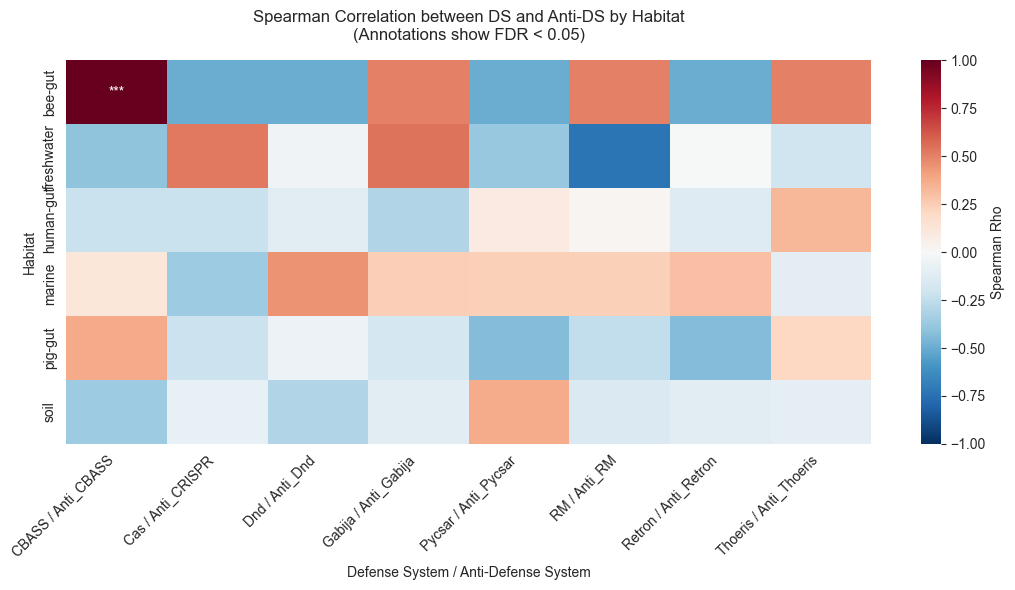

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# 1. 读入您的数据
df = pd.read_csv(r"D:\softerware_scientific_research\python_all_inone\py learning\pythonProject\prophage_project\huiyuan_ADS_DS\DS_ADS_spearman_matrix_CLR/DS_ADS_Spearman_Correlations.csv")

# 2. 数据预处理
# 将防卫系统(DS)与其反系统(Anti_DS)合并显示为 x 轴标签
df['DS_pair'] = df['DS'] + " / " + df['Anti_DS']

# 生成绘图需要的两个数据透视表：一个用于颜色映射 (相关系数)，一个用于星号标注 (FDR)
heatmap_data = df.pivot(index="Habitat", columns="DS_pair", values="Spearman_Rho")
fdr_data = df.pivot(index="Habitat", columns="DS_pair", values="FDR_Adjusted_P")

# 定义基于 FDR 调整 p 值的星号添加规则
def get_stars(val):
    if pd.isna(val):
        return ""
    elif val < 0.001:
        return "***"
    elif val < 0.01:
        return "**"
    elif val < 0.05:
        return "*"
    else:
        return ""

# 将星号规则应用到显著性数据表
annot_data = fdr_data.applymap(get_stars)

# 3. 绘图设置
plt.figure(figsize=(11, 6))

# 绘制热图：
# cmap="RdBu_r" 提供了蓝-白-红的红蓝渐变配色（适合展示 -1 到 1 的相关性）
# annot=annot_data 强制显示显著性星号
# vmin=-1, vmax=1 确保色条的中点(白色)精确对应数值 0
ax = sns.heatmap(heatmap_data, annot=annot_data, fmt="", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, cbar_kws={'label': 'Spearman Rho'})

plt.title('Spearman Correlation between DS and Anti-DS by Habitat\n(Annotations show FDR < 0.05)', pad=15)
plt.xlabel("Defense System / Anti-Defense System")
plt.ylabel("Habitat")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 4. 导出图表（如果需要高分辨率图片，可将后缀改成 .png 并加上 dpi=300 参数）
plt.savefig('heatmap_DS_AntiDS.pdf')
plt.show()